In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [11]:
data = load_wine()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print(X.head())
print(y.head())

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  
0                  

In [12]:
# Convert Wine dataset (3 classes) into Binary
# Class 0 -> 0
# Class 1 and 2 -> 1

y = (y != 0).astype(int)

print(y.value_counts())

1    119
0     59
Name: count, dtype: int64


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape)
print("Testing Samples :", X_test.shape)

Training Samples: (142, 13)
Testing Samples : (36, 13)


In [14]:
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

In [15]:
svm = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)

In [16]:
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.01, 0.001, 0.0001]
}

In [17]:
grid = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

grid.fit(X_train_sc, y_train)

print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'C': 1, 'gamma': 'scale'}


In [18]:
best_svm = grid.best_estimator_

best_svm.fit(X_train_sc, y_train)

SVC(C=1, probability=True, random_state=42)

In [19]:
y_pred = best_svm.predict(X_test_sc)

y_prob = best_svm.predict_proba(X_test_sc)[:,1]

In [20]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

cm = confusion_matrix(y_test, y_pred)

print("Accuracy :", acc)
print("Precision:", prec)
print("Recall :", rec)
print("F1 Score :", f1)
print("ROC AUC :", auc)

print("\nConfusion Matrix")
print(cm)

Accuracy : 1.0
Precision: 1.0
Recall : 1.0
F1 Score : 1.0
ROC AUC : 1.0

Confusion Matrix
[[12  0]
 [ 0 24]]


In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        24

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



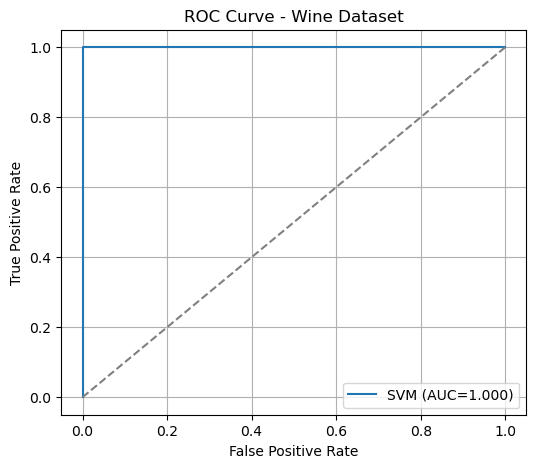

In [22]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"SVM (AUC={auc:.3f})")

plt.plot([0,1],[0,1],'--',color='gray')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Wine Dataset")

plt.legend()
plt.grid(True)

plt.show()